In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [17]:
#create a model class that inherits nn.Module
class Model(nn.Module):
    #input layer --> hidden layer --> hidden layer --> output
    def __init__(self, in_features = 21, h1 = 32, h2 = 16, out_features = 1):
        super().__init__() #instanciante nn.Module
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [18]:
#pick a manual seed for randomization
torch.manual_seed(41)

#create instance of model
model = Model()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
my_df = pd.read_csv("../data/X_train_balanced.csv")

In [21]:
my_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.896681,-1.110562,0.159201,-0.677784,-0.990786,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,-0.765354,-0.455382,-0.572176,-0.598325,-0.950983,0.849852,1.076524,1.062246
1,-1.188693,-1.110562,-6.447992,0.437708,-0.990786,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,0.156684,1.397341,-0.572176,-0.598325,1.142868,-0.565307,-0.949595,1.062246
2,0.896681,-1.110562,0.159201,0.437708,1.100773,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,1.078722,-0.455382,-0.372888,-0.598325,-0.950983,-0.211517,-0.949595,-1.271011
3,0.896681,0.973745,0.159201,-0.538347,1.100773,4.468666,2.631026,0.668982,0.819065,0.530123,...,0.219181,-0.327882,0.156684,-0.455382,-0.572176,1.819520,1.142868,1.203642,1.076524,-1.271011
4,0.896681,0.973745,0.159201,0.716581,1.100773,-0.263653,-0.434203,-1.652785,0.819065,0.530123,...,0.219181,-0.327882,1.078722,1.273826,0.025687,1.819520,-0.950983,0.849852,-2.975714,-2.204314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299179,-0.903323,0.973745,0.159201,2.548335,-0.990786,-0.263653,-0.434203,-1.335066,-1.338952,0.170075,...,0.219181,-0.327882,2.000760,2.666294,2.262952,1.819520,0.856337,-1.529849,-0.213798,-1.801521
299180,-0.945030,-0.867024,0.159201,-0.275767,-0.990786,-0.263653,-0.434203,0.668982,0.819065,0.530123,...,0.219181,-0.327882,0.156684,-0.208352,-0.384531,-0.598325,-0.950983,-0.170179,1.076524,0.650120
299181,0.896681,-1.110562,0.159201,-0.716712,-0.990786,3.147467,0.421568,0.668982,0.819065,0.530123,...,0.219181,-0.327882,-1.429972,-0.455382,-0.572176,-0.598325,-0.950983,1.557432,1.076524,0.465312
299182,0.224875,0.302283,0.159201,-0.398911,-0.316988,-0.263653,-0.434203,-0.904825,0.819065,0.530123,...,0.219181,-0.327882,0.781686,-0.455382,1.420700,1.819520,-0.950983,1.557432,0.423807,-0.654027


In [22]:
X_train = pd.read_csv("../data/X_train_balanced.csv")
y_train = pd.read_csv("../data/y_train_balanced.csv")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")

X_val = pd.read_csv("../data/X_val.csv")
y_val = pd.read_csv("../data/y_val.csv")

In [23]:
X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_val   = torch.tensor(X_val.values, dtype=torch.float32)
X_test  = torch.tensor(X_test.values, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long).squeeze()
y_val   = torch.tensor(y_val.values, dtype=torch.long).squeeze()
y_test  = torch.tensor(y_test.values, dtype=torch.long).squeeze()

In [24]:
#how far off predictions are from the data
criterion = torch.nn.BCEWithLogitsLoss()
#choose adam optmizer, lr = learning rate (if error doesn't go down after a bunch of iterations, lower learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


In [25]:
#train model
#epochs? one run through all training data
y_train_bce = y_train.float().view(-1, 1)
y_val_bce = y_val.float().view(-1, 1)

epochs = 100
losses = []
val_losses = []
for i in range(epochs):
    #go forward and get a prediction
    y_pred = model.forward(X_train) #get predicted results

    #measure the loss
    loss = criterion(y_pred, y_train_bce)

    #keep track of losses
    losses.append(loss.detach().cpu().item())

    #val
    model.eval()
    with torch.no_grad():
        val_pred = model.forward(X_val)
        val_loss = criterion(val_pred, y_val_bce)
        val_losses.append(val_loss.detach().cpu().item())
    model.train()
    #print every 1000 epoch
    if i % 10 == 0:
        print(f"Epoch: {i} and train loss: {loss} | val loss: {val_loss}")

    #do some backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Epoch: 0 and train loss: 0.709378182888031 | val loss: 0.6925002932548523
Epoch: 10 and train loss: 0.522066056728363 | val loss: 0.5141579508781433
Epoch: 20 and train loss: 0.4974009394645691 | val loss: 0.5047202110290527
Epoch: 30 and train loss: 0.48536476492881775 | val loss: 0.48890236020088196
Epoch: 40 and train loss: 0.4789656400680542 | val loss: 0.4924936592578888
Epoch: 50 and train loss: 0.4719742238521576 | val loss: 0.487427681684494
Epoch: 60 and train loss: 0.46314355731010437 | val loss: 0.4779893457889557
Epoch: 70 and train loss: 0.45019087195396423 | val loss: 0.470136433839798
Epoch: 80 and train loss: 0.43037042021751404 | val loss: 0.4556749761104584
Epoch: 90 and train loss: 0.4033640921115875 | val loss: 0.44198402762413025


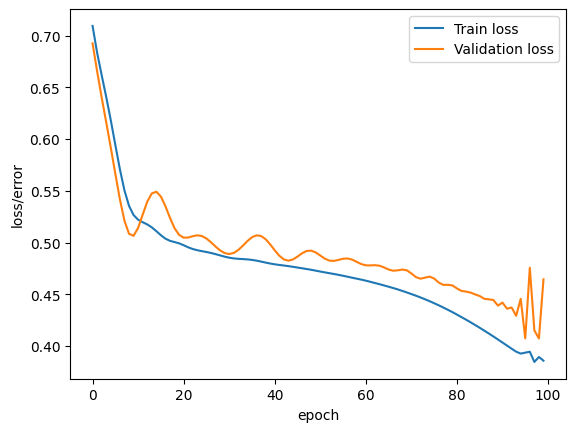

In [26]:
#graph it out
plt.figure() 
plt.plot(range(epochs), losses, label = "Train loss")
plt.plot(range(epochs), val_losses, label = "Validation loss")
plt.ylabel("loss/error")
plt.xlabel("epoch")
plt.legend()
plt.show()

In [27]:
#test
y_test_bce = y_test.float().view(-1, 1)
with torch.no_grad(): #turn off backpropagation
    y_eval = model.forward(X_test) #X_test are features from our test set, y_eval will be predictions
    loss = criterion(y_eval, y_test_bce) #find loss or error



In [28]:
loss

tensor(0.4288)

In [29]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        if y_test[i] == 0:
            x = "No diabetes"
        else:
            x = "Diabetes"
        
        prob = torch.sigmoid(y_val).item()
        pred = 1 if prob >= 0.5 else 0

        print(f"{i+1}.) {str(y_val)} \t {x} \t {(torch.sigmoid(y_val) >= 0.5).item()}")

        #correct or not
        if y_val.argmax().item() == y_test[i]:
            correct += 1
print(f"We got {correct} correct")
print(f"Accuracy: {correct/len(X_test):.4f}")
print("Test loss:", loss.item())

1.) tensor([0.9120]) 	 Diabetes 	 True
2.) tensor([-4.0501]) 	 No diabetes 	 False
3.) tensor([1.0783]) 	 No diabetes 	 True
4.) tensor([-3.3611]) 	 No diabetes 	 False
5.) tensor([-0.5535]) 	 No diabetes 	 False
6.) tensor([-0.3607]) 	 No diabetes 	 False
7.) tensor([-1.6144]) 	 No diabetes 	 False
8.) tensor([1.4354]) 	 No diabetes 	 True
9.) tensor([-2.5122]) 	 No diabetes 	 False
10.) tensor([-1.5735]) 	 No diabetes 	 False
11.) tensor([-2.3263]) 	 No diabetes 	 False
12.) tensor([-1.0577]) 	 No diabetes 	 False
13.) tensor([1.4379]) 	 Diabetes 	 True
14.) tensor([-1.5342]) 	 No diabetes 	 False
15.) tensor([-3.1310]) 	 No diabetes 	 False
16.) tensor([-2.6434]) 	 No diabetes 	 False
17.) tensor([-2.5255]) 	 No diabetes 	 False
18.) tensor([-4.7534]) 	 No diabetes 	 False
19.) tensor([-1.4462]) 	 No diabetes 	 False
20.) tensor([-0.3093]) 	 No diabetes 	 False
21.) tensor([-1.6707]) 	 No diabetes 	 False
22.) tensor([-2.4162]) 	 No diabetes 	 False
23.) tensor([-2.7286]) 	 No diabe

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

with torch.no_grad():
    logits = model(X_test).squeeze()
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.6).int()

print("Precision:", precision_score(y_test.numpy(), preds.numpy()))
print("Recall:", recall_score(y_test.numpy(), preds.numpy()))
print("F1:", f1_score(y_test.numpy(), preds.numpy()))
print("ROC-AUC:", roc_auc_score(y_test.numpy(), probs.numpy()))

Precision: 0.4096456403470078
Recall: 0.5254620897774425
F1: 0.46038172353961826
ROC-AUC: 0.8182502721566944
